<a href="https://colab.research.google.com/github/Preethi-140306/MLOPS_Training/blob/main/PROJECT_IMPLEMENTED_KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving processed_women_safety.csv to processed_women_safety.csv


In [3]:
import pandas as pd
df = pd.read_csv('processed_women_safety.csv')
df.head()

,id,text,label,confidence_score,camera_id,location,time,state,split,clean_text,...,city_Namakkal,city_Salem,city_Sivakasi,city_Thanjavur,city_Thoothukudi,city_Tiruchirappalli,city_Tirunelveli,city_Tiruppur,city_Vellore,hour
0,1,"Night patrol AI report — Koyambedu market, Tha...",lone_walking_night,0.370370,260,15,10:45 PM,Tamil Nadu,val,night patrol ai report koyambedu market thanja...,...,False,False,False,True,False,False,False,False,False,22
1,2,AI flagged aggressive group posture near femal...,group_harassment,0.629630,232,5,2:30 AM,Tamil Nadu,train,ai flagged aggressive group posture near femal...,...,False,False,False,False,False,False,False,False,False,2
2,3,"Woman at Salem Steel Plant road, Thoothukudi a...",safe,0.555556,552,33,9:30 PM,Tamil Nadu,train,woman at salem steel plant road thoothukudi at...,...,False,False,False,False,True,False,False,False,False,21
3,4,Woman detected walking alone near Goripalayam ...,lone_walking_night,0.555556,916,9,3:30 AM,Tamil Nadu,val,woman detected walking alone near goripalayam ...,...,False,False,False,False,False,False,False,False,True,3
4,5,Stalking behaviour detected at VOC Park pathwa...,being_followed,0.666667,668,44,3:30 AM,Tamil Nadu,train,stalking behaviour detected at voc park pathwa...,...,False,False,False,False,False,False,False,False,False,3


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_text = tfidf.fit_transform(df['clean_text'])


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num = scaler.fit_transform(df[['hour', 'confidence_score']])
X = hstack([X_text, X_num])

In [8]:
from sklearn.cluster import KMeans
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)


KMeans(n_clusters=4, random_state=42)

In [9]:
df['cluster'] = kmeans.labels_
print(df[['clean_text', 'cluster']].head())

                                          clean_text  cluster
0  night patrol ai report koyambedu market thanja...        1
1  ai flagged aggressive group posture near femal...        0
2  woman at salem steel plant road thoothukudi at...        2
3  woman detected walking alone near goripalayam ...        0
4  stalking behaviour detected at voc park pathwa...        0


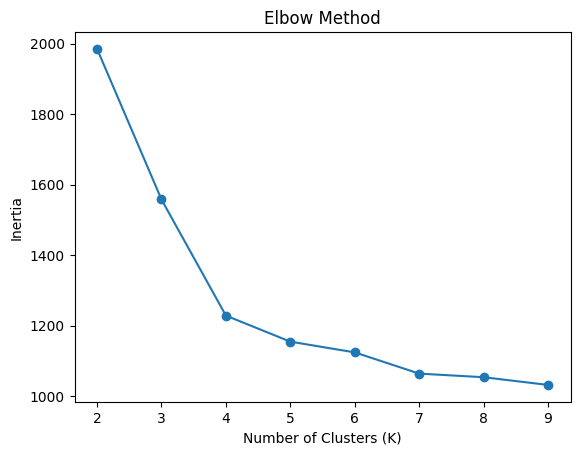

In [10]:
import matplotlib.pyplot as plt
inertia = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
import pickle
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('kmeans_model.pkl','rb') as f:
    kmeans=pickle.load(f)